<a href="https://colab.research.google.com/github/codekiller9/skills-introduction-to-github/blob/main/SVPWM_simulation_Yixiao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Figures will be saved to: /content


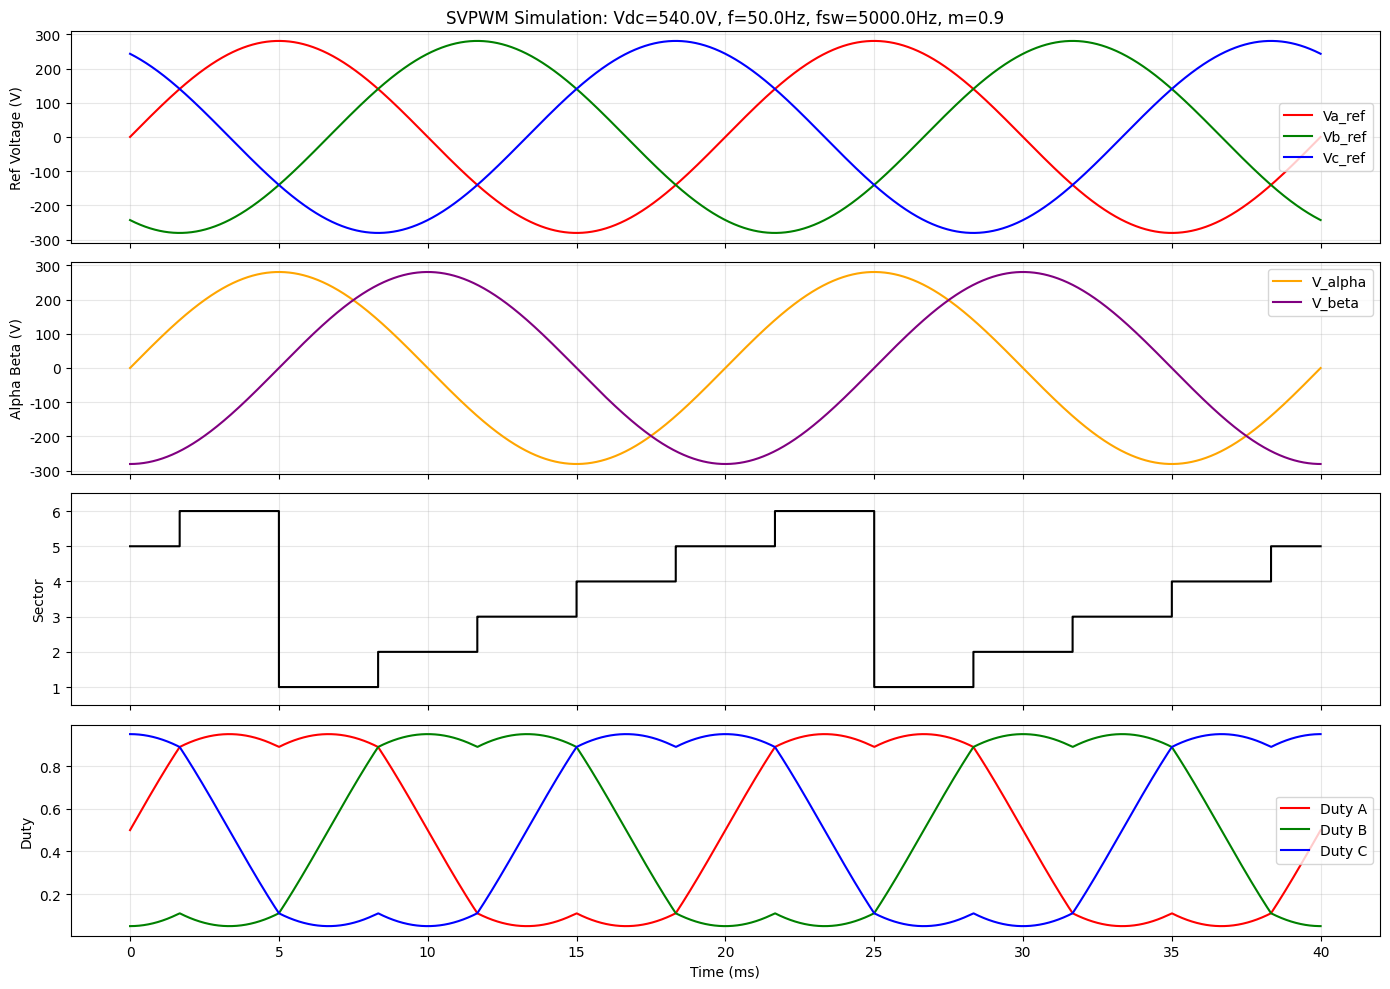

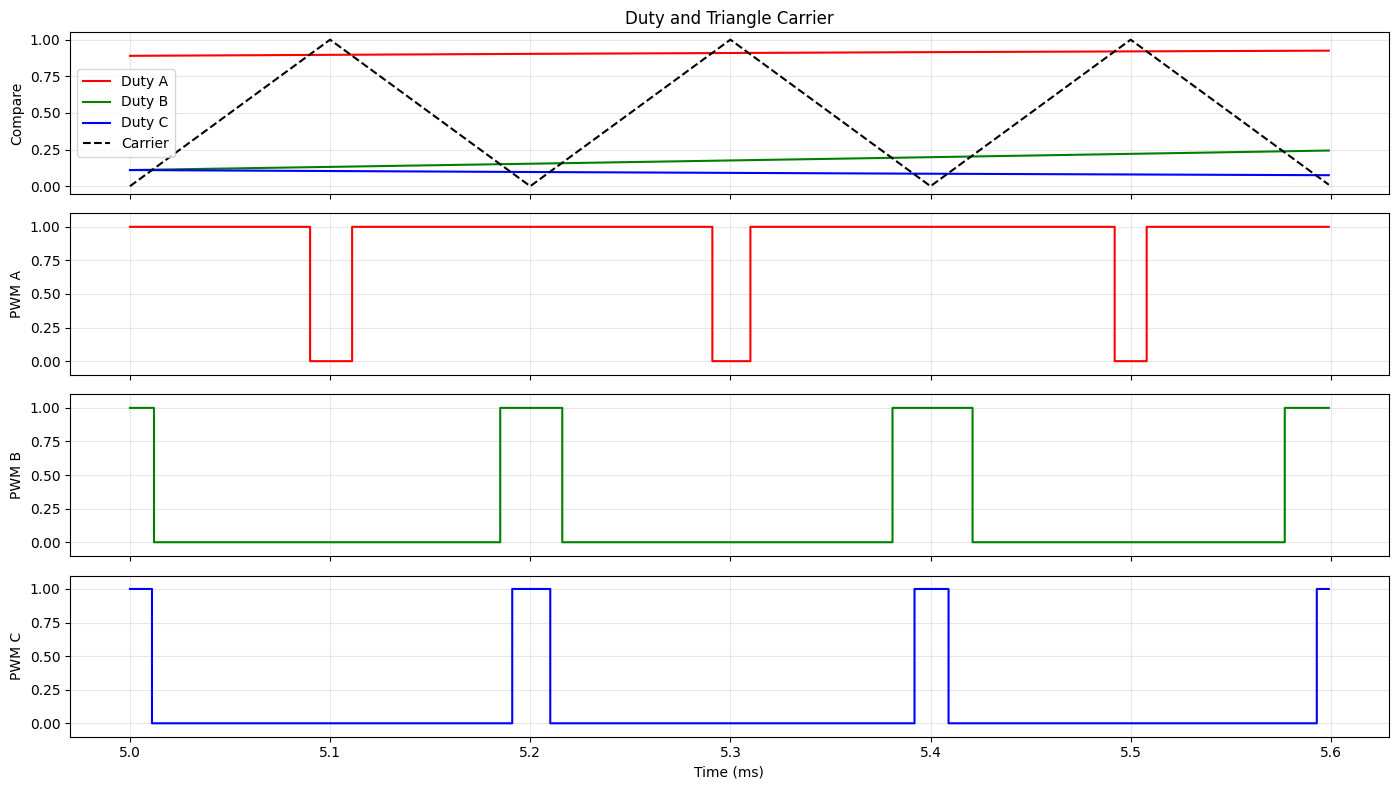

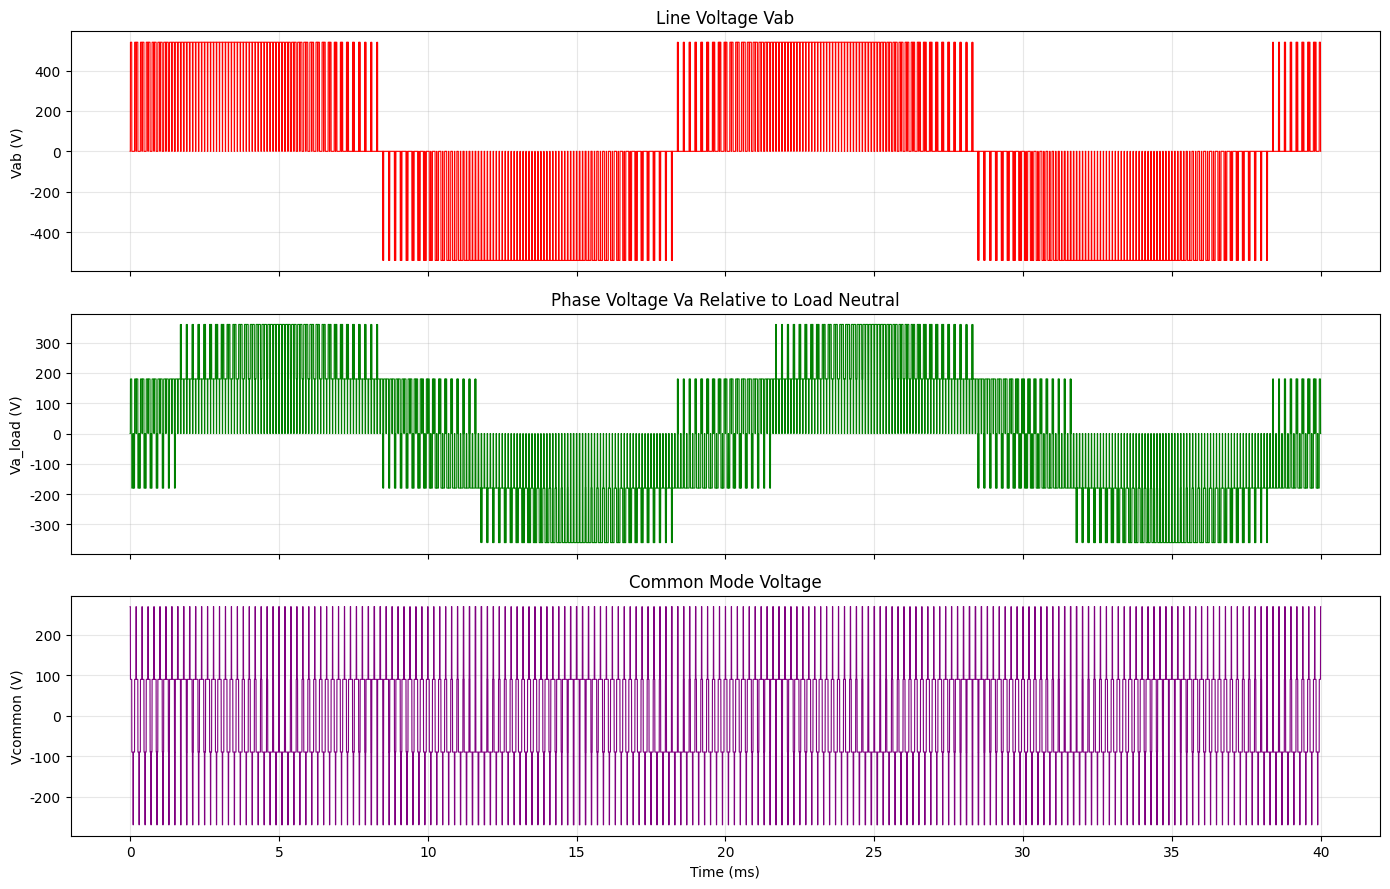

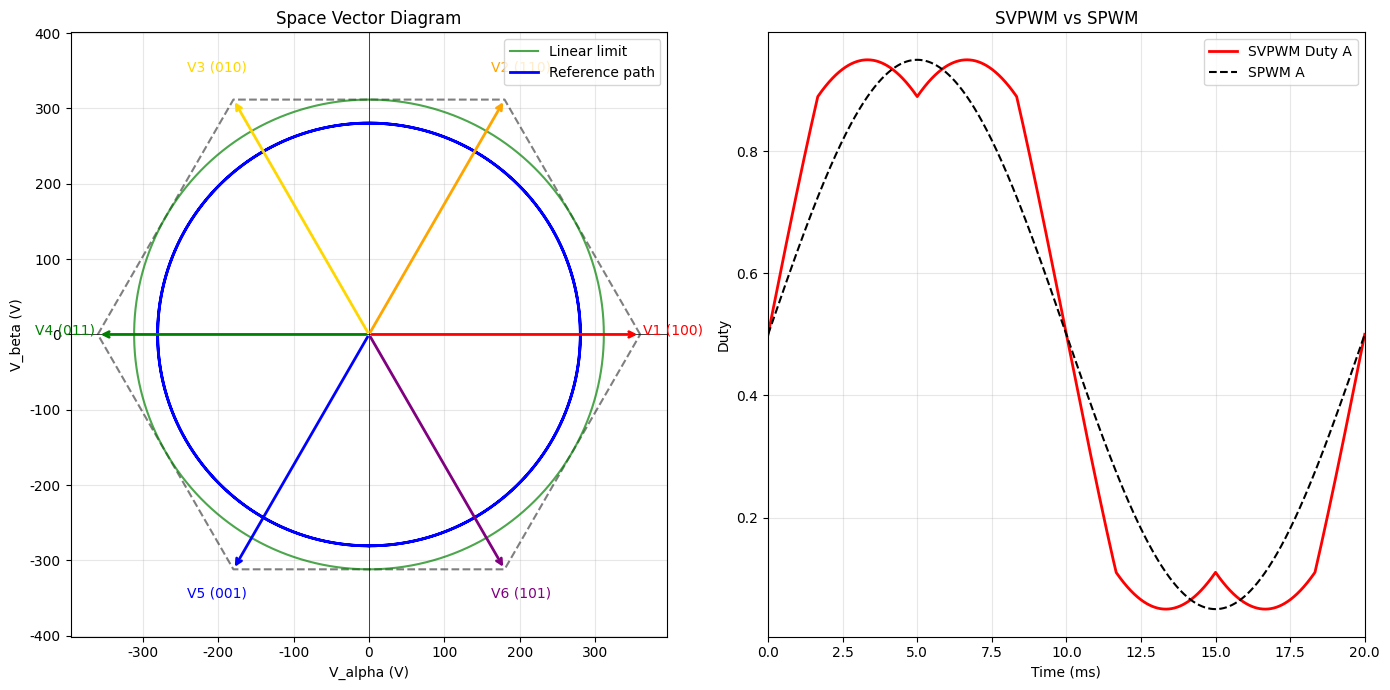

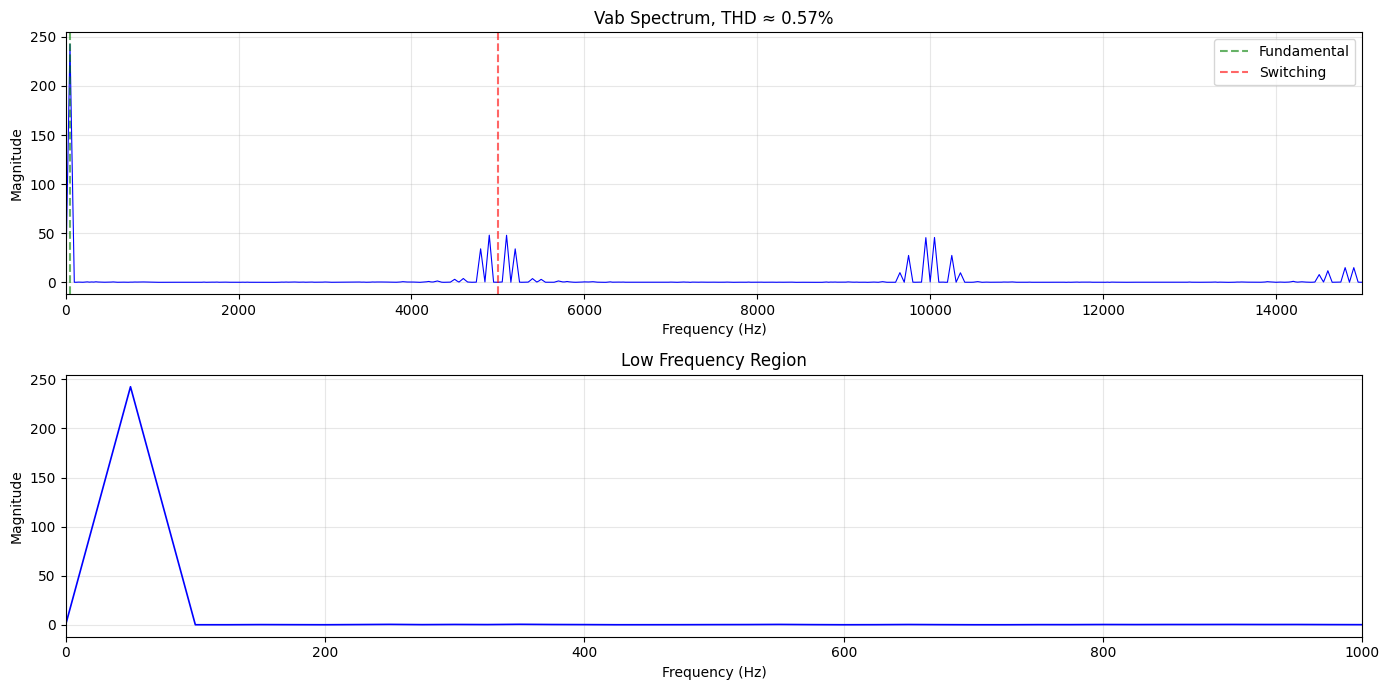

SVPWM Simulation Results
DC bus voltage          : 540.0 V
Fundamental frequency   : 50.0 Hz
Switching frequency     : 5000.0 Hz
Modulation index        : 0.900
Max alpha-beta magnitude: 280.59 V
Linear limit            : 311.77 V
--------------------------------------------------
Duty A range            : [0.050, 0.950]
Duty B range            : [0.050, 0.950]
Duty C range            : [0.050, 0.950]
Fundamental Vab         : 242.50
THD estimate            : 0.57%
All figures are saved in: /content


In [5]:
"""
Simple SVPWM simulation in Python
All figures are saved in the current working folder
"""

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

save_dir = os.getcwd()
print(f"Figures will be saved to: {save_dir}")

# ============================================================
# Basic parameters
# ============================================================
Vdc = 540.0              # DC bus voltage (V)
f_ref = 50.0             # fundamental frequency (Hz)
f_sw = 5000.0            # switching frequency (Hz)
Ts = 1.0 / f_sw          # switching period (s)
m = 0.9                  # modulation index
t_sim = 0.04             # total simulation time (s)
dt = Ts / 200            # simulation step

t = np.arange(0, t_sim, dt)
N = len(t)

# ============================================================
# Step 1: Generate three-phase reference signals
# ============================================================
Vm = m * Vdc / np.sqrt(3)
w = 2 * np.pi * f_ref

Va_ref = Vm * np.sin(w * t)
Vb_ref = Vm * np.sin(w * t - 2 * np.pi / 3)
Vc_ref = Vm * np.sin(w * t + 2 * np.pi / 3)

# ============================================================
# Step 2: Clarke transform
# ============================================================
V_alpha = (2 / 3) * (Va_ref - 0.5 * Vb_ref - 0.5 * Vc_ref)
V_beta = (2 / 3) * ((np.sqrt(3) / 2) * Vb_ref - (np.sqrt(3) / 2) * Vc_ref)

V_mag = np.sqrt(V_alpha**2 + V_beta**2)

# ============================================================
# Step 3: SVPWM core function
# ============================================================
def svpwm_core(Va, Vb, Vc, Vdc, Ts):
    # Clarke transform inside the function
    Valpha = (2 / 3) * (Va - 0.5 * Vb - 0.5 * Vc)
    Vbeta = (2 / 3) * ((np.sqrt(3) / 2) * Vb - (np.sqrt(3) / 2) * Vc)

    # Values used for sector decision
    Vref1 = Vbeta
    Vref2 = (np.sqrt(3) / 2) * Valpha - 0.5 * Vbeta
    Vref3 = -(np.sqrt(3) / 2) * Valpha - 0.5 * Vbeta

    A = 1 if Vref1 > 0 else 0
    B = 1 if Vref2 > 0 else 0
    C = 1 if Vref3 > 0 else 0

    code = A + 2 * B + 4 * C

    # Sector map
    if code == 3:
        sector = 1
    elif code == 1:
        sector = 2
    elif code == 5:
        sector = 3
    elif code == 4:
        sector = 4
    elif code == 6:
        sector = 5
    elif code == 2:
        sector = 6
    else:
        sector = 1

    # X, Y, Z values
    X = np.sqrt(3) * Ts * Vbeta / Vdc
    Y = Ts * (1.5 * Valpha + (np.sqrt(3) / 2) * Vbeta) / Vdc
    Z = Ts * (-1.5 * Valpha + (np.sqrt(3) / 2) * Vbeta) / Vdc

    # Get T1 and T2 from sector
    if sector == 1:
        T1 = -Z
        T2 = X
    elif sector == 2:
        T1 = Z
        T2 = Y
    elif sector == 3:
        T1 = X
        T2 = -Y
    elif sector == 4:
        T1 = -X
        T2 = Z
    elif sector == 5:
        T1 = -Y
        T2 = -Z
    else:  # sector == 6
        T1 = Y
        T2 = -X

    # Avoid negative values
    T1 = max(T1, 0.0)
    T2 = max(T2, 0.0)

    # Limit if T1 + T2 is too large
    if T1 + T2 > Ts:
        scale = Ts / (T1 + T2)
        T1 = T1 * scale
        T2 = T2 * scale

    T0 = Ts - T1 - T2

    # Symmetrical switching times
    Taon = T0 / 4
    Tbon = Taon + T1 / 2
    Tcon = Tbon + T2 / 2

    # Arrange times for each sector
    if sector == 1:
        Ta, Tb, Tc = Taon, Tbon, Tcon
    elif sector == 2:
        Ta, Tb, Tc = Tbon, Taon, Tcon
    elif sector == 3:
        Ta, Tb, Tc = Tcon, Taon, Tbon
    elif sector == 4:
        Ta, Tb, Tc = Tcon, Tbon, Taon
    elif sector == 5:
        Ta, Tb, Tc = Tbon, Tcon, Taon
    else:  # sector == 6
        Ta, Tb, Tc = Taon, Tcon, Tbon

    # Duty ratio in [0, 1]
    duty_a = 1.0 - 2.0 * Ta / Ts
    duty_b = 1.0 - 2.0 * Tb / Ts
    duty_c = 1.0 - 2.0 * Tc / Ts

    duty_a = np.clip(duty_a, 0.0, 1.0)
    duty_b = np.clip(duty_b, 0.0, 1.0)
    duty_c = np.clip(duty_c, 0.0, 1.0)

    return sector, T1, T2, T0, duty_a, duty_b, duty_c

# ============================================================
# Step 4: Run SVPWM for all time points
# ============================================================
sector_arr = np.zeros(N)
T1_arr = np.zeros(N)
T2_arr = np.zeros(N)
T0_arr = np.zeros(N)
duty_a_arr = np.zeros(N)
duty_b_arr = np.zeros(N)
duty_c_arr = np.zeros(N)

for i in range(N):
    sector, T1, T2, T0, duty_a, duty_b, duty_c = svpwm_core(
        Va_ref[i], Vb_ref[i], Vc_ref[i], Vdc, Ts
    )
    sector_arr[i] = sector
    T1_arr[i] = T1
    T2_arr[i] = T2
    T0_arr[i] = T0
    duty_a_arr[i] = duty_a
    duty_b_arr[i] = duty_b
    duty_c_arr[i] = duty_c

# ============================================================
# Step 5: Create triangle carrier
# ============================================================
carrier = np.zeros(N)

for i in range(N):
    phase = (t[i] % Ts) / Ts
    if phase < 0.5:
        carrier[i] = 2 * phase
    else:
        carrier[i] = 2 * (1 - phase)

# ============================================================
# Step 6: Generate PWM signals
# ============================================================
PWM_A = (duty_a_arr > carrier).astype(float)
PWM_B = (duty_b_arr > carrier).astype(float)
PWM_C = (duty_c_arr > carrier).astype(float)

# ============================================================
# Step 7: Inverter output voltages
# ============================================================
Va_pole = (PWM_A - 0.5) * Vdc
Vb_pole = (PWM_B - 0.5) * Vdc
Vc_pole = (PWM_C - 0.5) * Vdc

V_common = (Va_pole + Vb_pole + Vc_pole) / 3

Va_load = Va_pole - V_common
Vb_load = Vb_pole - V_common
Vc_load = Vc_pole - V_common

Vab = Va_pole - Vb_pole
Vbc = Vb_pole - Vc_pole
Vca = Vc_pole - Va_pole

# ============================================================
# Figure 1: Reference and duty ratio
# ============================================================
fig1, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t * 1000, Va_ref, "r", label="Va_ref")
axes[0].plot(t * 1000, Vb_ref, "g", label="Vb_ref")
axes[0].plot(t * 1000, Vc_ref, "b", label="Vc_ref")
axes[0].set_ylabel("Ref Voltage (V)")
axes[0].set_title(f"SVPWM Simulation: Vdc={Vdc}V, f={f_ref}Hz, fsw={f_sw}Hz, m={m}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t * 1000, V_alpha, color="orange", label="V_alpha")
axes[1].plot(t * 1000, V_beta, color="purple", label="V_beta")
axes[1].set_ylabel("Alpha Beta (V)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t * 1000, sector_arr, "k", drawstyle="steps-post")
axes[2].set_ylabel("Sector")
axes[2].set_yticks([1, 2, 3, 4, 5, 6])
axes[2].set_ylim(0.5, 6.5)
axes[2].grid(True, alpha=0.3)

axes[3].plot(t * 1000, duty_a_arr, "r", label="Duty A")
axes[3].plot(t * 1000, duty_b_arr, "g", label="Duty B")
axes[3].plot(t * 1000, duty_c_arr, "b", label="Duty C")
axes[3].set_ylabel("Duty")
axes[3].set_xlabel("Time (ms)")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "fig1_reference_duty.png"), dpi=120, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# Figure 2: PWM signals
# ============================================================
fig2, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

zoom_start = int(0.005 / dt)
zoom_end = zoom_start + int(3 * Ts / dt)
t_zoom = t[zoom_start:zoom_end] * 1000

axes[0].plot(t_zoom, duty_a_arr[zoom_start:zoom_end], "r", label="Duty A")
axes[0].plot(t_zoom, duty_b_arr[zoom_start:zoom_end], "g", label="Duty B")
axes[0].plot(t_zoom, duty_c_arr[zoom_start:zoom_end], "b", label="Duty C")
axes[0].plot(t_zoom, carrier[zoom_start:zoom_end], "k--", label="Carrier")
axes[0].set_ylabel("Compare")
axes[0].set_title("Duty and Triangle Carrier")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_zoom, PWM_A[zoom_start:zoom_end], "r", drawstyle="steps-post")
axes[1].set_ylabel("PWM A")
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_zoom, PWM_B[zoom_start:zoom_end], "g", drawstyle="steps-post")
axes[2].set_ylabel("PWM B")
axes[2].set_ylim(-0.1, 1.1)
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_zoom, PWM_C[zoom_start:zoom_end], "b", drawstyle="steps-post")
axes[3].set_ylabel("PWM C")
axes[3].set_xlabel("Time (ms)")
axes[3].set_ylim(-0.1, 1.1)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "fig2_pwm_signals.png"), dpi=120, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# Figure 3: Inverter output voltages
# ============================================================
fig3, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(t * 1000, Vab, "r", linewidth=0.8)
axes[0].set_ylabel("Vab (V)")
axes[0].set_title("Line Voltage Vab")
axes[0].set_ylim(-1.1 * Vdc, 1.1 * Vdc)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t * 1000, Va_load, "g", linewidth=0.8)
axes[1].set_ylabel("Va_load (V)")
axes[1].set_title("Phase Voltage Va Relative to Load Neutral")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t * 1000, V_common, color="purple", linewidth=0.8)
axes[2].set_ylabel("Vcommon (V)")
axes[2].set_xlabel("Time (ms)")
axes[2].set_title("Common Mode Voltage")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "fig3_output_voltage.png"), dpi=120, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# Figure 4: Space vector plot
# ============================================================
fig4, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]

vectors = [
    (Vdc * 2 / 3, 0, "V1 (100)"),
    (Vdc / 3, Vdc * np.sqrt(3) / 3, "V2 (110)"),
    (-Vdc / 3, Vdc * np.sqrt(3) / 3, "V3 (010)"),
    (-Vdc * 2 / 3, 0, "V4 (011)"),
    (-Vdc / 3, -Vdc * np.sqrt(3) / 3, "V5 (001)"),
    (Vdc / 3, -Vdc * np.sqrt(3) / 3, "V6 (101)")
]

colors = ["red", "orange", "gold", "green", "blue", "purple"]

for (vx, vy, name), c in zip(vectors, colors):
    ax.annotate("", xy=(vx, vy), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(vx * 1.12, vy * 1.12, name, fontsize=10, ha="center", color=c)

hex_x = [v[0] for v in vectors] + [vectors[0][0]]
hex_y = [v[1] for v in vectors] + [vectors[0][1]]
ax.plot(hex_x, hex_y, "k--", alpha=0.5)

theta = np.linspace(0, 2 * np.pi, 200)
Rmax = Vdc / np.sqrt(3)
ax.plot(Rmax * np.cos(theta), Rmax * np.sin(theta), "g-", alpha=0.7, label="Linear limit")

ax.plot(V_alpha, V_beta, "b", linewidth=2, label="Reference path")

ax.set_xlabel("V_alpha (V)")
ax.set_ylabel("V_beta (V)")
ax.set_title("Space Vector Diagram")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.axhline(0, color="k", linewidth=0.5)
ax.axvline(0, color="k", linewidth=0.5)
ax.legend()

ax2 = axes[1]
spwm_a = 0.5 + 0.5 * m * np.sin(w * t)

ax2.plot(t * 1000, duty_a_arr, "r", linewidth=2, label="SVPWM Duty A")
ax2.plot(t * 1000, spwm_a, "k--", linewidth=1.5, label="SPWM A")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Duty")
ax2.set_title("SVPWM vs SPWM")
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xlim(0, 20)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "fig4_space_vector.png"), dpi=120, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# Figure 5: FFT
# ============================================================
fs = 1 / dt
window = np.hanning(N)
Vab_fft = np.fft.fft(Vab * window) / N * 2
freqs = np.fft.fftfreq(N, dt)

mask = freqs >= 0
freqs_pos = freqs[mask]
Vab_mag = np.abs(Vab_fft[mask])

fund_idx = np.argmin(np.abs(freqs_pos - f_ref))
V1 = Vab_mag[fund_idx]

harmonic_sum = 0.0
for h in range(2, 50):
    idx = np.argmin(np.abs(freqs_pos - h * f_ref))
    if idx < len(Vab_mag):
        harmonic_sum += Vab_mag[idx] ** 2

THD = np.sqrt(harmonic_sum) / V1 * 100

fig5, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(freqs_pos, Vab_mag, "b", linewidth=0.8)
axes[0].set_xlim(0, 3 * f_sw)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude")
axes[0].set_title(f"Vab Spectrum, THD ≈ {THD:.2f}%")
axes[0].grid(True, alpha=0.3)
axes[0].axvline(f_ref, color="g", linestyle="--", alpha=0.6, label="Fundamental")
axes[0].axvline(f_sw, color="r", linestyle="--", alpha=0.6, label="Switching")
axes[0].legend()

axes[1].plot(freqs_pos, Vab_mag, "b", linewidth=1.2)
axes[1].set_xlim(0, 20 * f_ref)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
axes[1].set_title("Low Frequency Region")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "fig5_fft.png"), dpi=120, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# Print results
# ============================================================
print("=" * 50)
print("SVPWM Simulation Results")
print("=" * 50)
print(f"DC bus voltage          : {Vdc:.1f} V")
print(f"Fundamental frequency   : {f_ref:.1f} Hz")
print(f"Switching frequency     : {f_sw:.1f} Hz")
print(f"Modulation index        : {m:.3f}")
print(f"Max alpha-beta magnitude: {np.max(V_mag):.2f} V")
print(f"Linear limit            : {Vdc / np.sqrt(3):.2f} V")
print("-" * 50)
print(f"Duty A range            : [{duty_a_arr.min():.3f}, {duty_a_arr.max():.3f}]")
print(f"Duty B range            : [{duty_b_arr.min():.3f}, {duty_b_arr.max():.3f}]")
print(f"Duty C range            : [{duty_c_arr.min():.3f}, {duty_c_arr.max():.3f}]")
print(f"Fundamental Vab         : {V1:.2f}")
print(f"THD estimate            : {THD:.2f}%")
print("=" * 50)
print(f"All figures are saved in: {save_dir}")